# Griffiths QM
## Chapter 12: Afterword — Visualizations (Problem Solutions)

**Repository:** SeoulTechPSE/introduction_to_quantum_mechanics

| Section | Problem | Notebook? |
|:--|:--|:--|
| §12.2 | 12.2 CHSH Violation — Optimal Angles | ✓ |
| §12.3 | 12.3 Purity of a Bloch-Sphere State | ✓ |
| §12.5 | 12.6 Decoherence Timescale Estimate | ✓ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'; ORG='#d35400'
figures = []
print('Setup complete.')

Setup complete.


---
## Problem 12.2 — CHSH Violation: Optimal Angles {#md_12_2}

$$S(\theta) = -2(\cos\theta+\sin\theta) = -2\sqrt{2}\sin(\theta+\pi/4)$$

Maximum $|S|=2\sqrt{2}$ at $\theta=45^\circ$ — the singlet, with this one-parameter setting, saturates Tsirelson's bound exactly at the textbook optimal angles ($a=0^\circ,a'=90^\circ,b=45^\circ,b'=135^\circ$).

max |S| = 2.828422 at theta = 45.11 deg
Tsirelson bound 2*sqrt(2) = 2.828427
Classical bound = 2


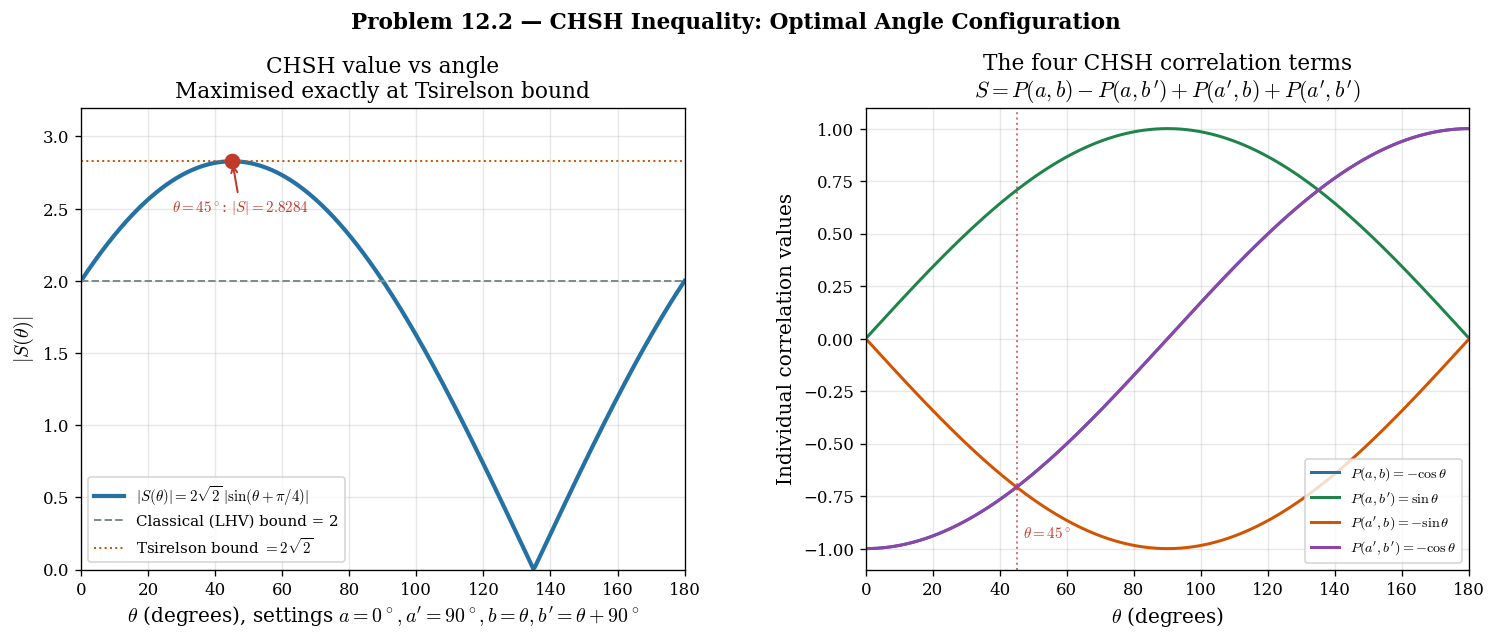

In [2]:

# Problem 12.2: CHSH value S(theta) = -2(cos(theta)+sin(theta)) for the
# one-parameter setting a=0, a'=90deg, b=theta, b'=theta+90deg

theta = np.linspace(0, np.pi, 400)
S = -2*(np.cos(theta) + np.sin(theta))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: S(theta), with classical/Tsirelson bounds
ax = axes[0]
ax.plot(np.degrees(theta), np.abs(S), color=BLUE, lw=2.5,
        label=r'$|S(\theta)|=2\sqrt{2}\,|\sin(\theta+\pi/4)|$')
ax.axhline(2, color=GRAY, ls='--', lw=1.2, label='Classical (LHV) bound = 2')
ax.axhline(2*np.sqrt(2), color=ORG, ls=':', lw=1.2, label=r'Tsirelson bound $=2\sqrt{2}$')
idx_max = np.argmax(np.abs(S))
theta_max_deg = np.degrees(theta[idx_max])
ax.scatter([theta_max_deg],[abs(S[idx_max])], color=RED, s=70, zorder=5)
ax.annotate(fr'$\theta={theta_max_deg:.0f}^\circ$: $|S|={abs(S[idx_max]):.4f}$',
             xy=(theta_max_deg, abs(S[idx_max])),
             xytext=(theta_max_deg-18, abs(S[idx_max])-0.35),
             fontsize=9, color=RED, arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))
ax.set_xlabel(r'$\theta$ (degrees), settings $a=0^\circ,a^\prime=90^\circ,b=\theta,b^\prime=\theta+90^\circ$')
ax.set_ylabel(r'$|S(\theta)|$')
ax.set_title('CHSH value vs angle\nMaximised exactly at Tsirelson bound')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.set_xlim(0,180); ax.set_ylim(0,3.2)

print(f"max |S| = {abs(S).max():.6f} at theta = {theta_max_deg:.2f} deg")
print(f"Tsirelson bound 2*sqrt(2) = {2*np.sqrt(2):.6f}")
print(f"Classical bound = 2")

# Right: the four individual correlations P(a,b),P(a,b'),P(a',b),P(a',b') vs theta
ax2 = axes[1]
Pab   = -np.cos(theta)
Pabp  =  np.sin(theta)
Papb  = -np.sin(theta)
Papbp = -np.cos(theta)
for arr, lbl, c in [(Pab,'$P(a,b)=-\\cos\\theta$',BLUE),
                     (Pabp,"$P(a,b')=\\sin\\theta$",GREEN),
                     (Papb,"$P(a',b)=-\\sin\\theta$",ORG),
                     (Papbp,"$P(a',b')=-\\cos\\theta$",PURP)]:
    ax2.plot(np.degrees(theta), arr, color=c, lw=1.8, label=lbl)
ax2.axvline(45, color=RED, ls=':', lw=1.2, alpha=0.7)
ax2.text(47, -0.95, r'$\theta=45^\circ$', color=RED, fontsize=9)
ax2.set_xlabel(r'$\theta$ (degrees)')
ax2.set_ylabel('Individual correlation values')
ax2.set_title('The four CHSH correlation terms\n'
               r'$S=P(a,b)-P(a,b^\prime)+P(a^\prime,b)+P(a^\prime,b^\prime)$')
ax2.legend(fontsize=8.5); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0,180); ax2.set_ylim(-1.1,1.1)

plt.suptitle('Problem 12.2 — CHSH Inequality: Optimal Angle Configuration',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_12_2.png')); plt.show()


---
## Problem 12.3 — Purity of a Bloch-Sphere State {#md_12_3}

$$\mathrm{Tr}\hat\rho^2=\frac{1}{2}(1+|\mathbf{r}|^2), \qquad \lambda_\pm=\frac{1\pm|\mathbf{r}|}{2}$$

Pure states live on the Bloch sphere surface ($|\mathbf{r}|=1$); the purity is a simple quadratic function of the distance from the center.

Tr(rho^2) at |r|=0: 0.500  (expect 0.5)
Tr(rho^2) at |r|=1: 1.000  (expect 1.0)
At |r|=1: lambda_+ = 1.00, lambda_- = 0.00  (rank-1 pure projector)
At |r|=0: lambda_+ = lambda_- = 0.50  (maximally mixed)


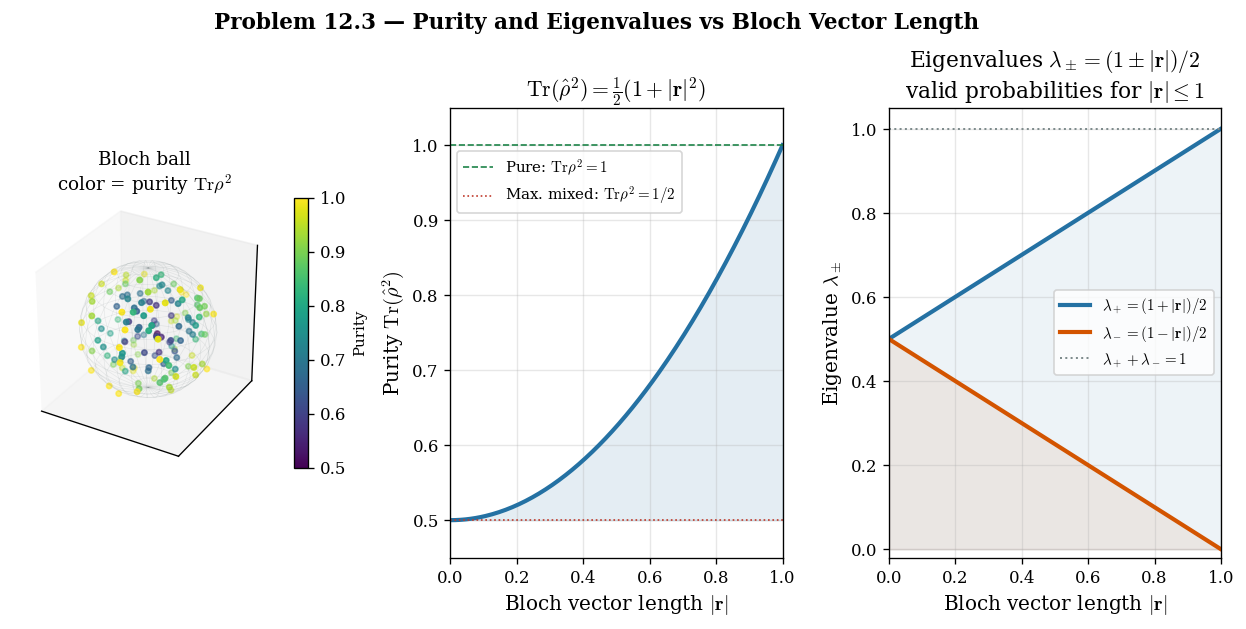

In [3]:

# Problem 12.3: Purity Tr(rho^2) = (1+|r|^2)/2 and eigenvalues (1+-|r|)/2

fig = plt.figure(figsize=(13, 5.0))
plt.subplots_adjust(top=0.86, wspace=0.32)

# Left: 3D Bloch ball with sample points colored by purity
ax = fig.add_subplot(1, 3, 1, projection='3d')
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
xs, ys, zs = np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v)
ax.plot_wireframe(xs, ys, zs, color=GRAY, alpha=0.15, linewidth=0.4)

np.random.seed(3)
n_pts = 400
pts = (np.random.rand(n_pts,3)-0.5)*2.4
r_norm = np.linalg.norm(pts, axis=1)
mask = r_norm <= 1.05
pts, r_norm = pts[mask], r_norm[mask]
purity = 0.5*(1+r_norm**2)
sc = ax.scatter(pts[:,0],pts[:,1],pts[:,2], c=purity, cmap='viridis', s=10, vmin=0.5, vmax=1.0)
ax.set_title('Bloch ball\ncolor = purity $\\mathrm{Tr}\\rho^2$', fontsize=11)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_box_aspect([1,1,1])
cb = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.05)
cb.set_label('Purity', fontsize=9)

# Middle: Tr(rho^2) vs |r|
ax2 = fig.add_subplot(1, 3, 2)
r_arr = np.linspace(0, 1, 200)
purity_arr = 0.5*(1+r_arr**2)
ax2.plot(r_arr, purity_arr, color=BLUE, lw=2.5)
ax2.axhline(1.0, color=GREEN, ls='--', lw=1, label='Pure: $\\mathrm{Tr}\\rho^2=1$')
ax2.axhline(0.5, color=RED, ls=':', lw=1, label='Max. mixed: $\\mathrm{Tr}\\rho^2=1/2$')
ax2.fill_between(r_arr, 0.5, purity_arr, alpha=0.12, color=BLUE)
ax2.set_xlabel(r'Bloch vector length $|\mathbf{r}|$')
ax2.set_ylabel(r'Purity $\mathrm{Tr}(\hat\rho^2)$')
ax2.set_title(r'$\mathrm{Tr}(\hat\rho^2)=\frac{1}{2}(1+|\mathbf{r}|^2)$')
ax2.legend(fontsize=9, bbox_to_anchor=(0.72,0.92)); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0,1); ax2.set_ylim(0.45,1.05)
print(f"Tr(rho^2) at |r|=0: {0.5*(1+0**2):.3f}  (expect 0.5)")
print(f"Tr(rho^2) at |r|=1: {0.5*(1+1**2):.3f}  (expect 1.0)")

# Right: eigenvalues lambda_+/- vs |r|
ax3 = fig.add_subplot(1, 3, 3)
lam_p = (1+r_arr)/2
lam_m = (1-r_arr)/2
ax3.plot(r_arr, lam_p, color=BLUE,  lw=2.5, label=r'$\lambda_+=(1+|\mathbf{r}|)/2$')
ax3.plot(r_arr, lam_m, color=ORG,   lw=2.5, label=r'$\lambda_-=(1-|\mathbf{r}|)/2$')
ax3.plot(r_arr, lam_p+lam_m, color=GRAY, lw=1.2, ls=':', label=r'$\lambda_++\lambda_-=1$')
ax3.fill_between(r_arr, 0, lam_p, alpha=0.08, color=BLUE)
ax3.fill_between(r_arr, 0, lam_m, alpha=0.08, color=ORG)
ax3.set_xlabel(r'Bloch vector length $|\mathbf{r}|$')
ax3.set_ylabel(r'Eigenvalue $\lambda_\pm$')
ax3.set_title(r'Eigenvalues $\lambda_\pm=(1\pm|\mathbf{r}|)/2$' + '\n'
              'valid probabilities for $|\\mathbf{r}|\\leq1$')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)
ax3.set_xlim(0,1); ax3.set_ylim(-0.02,1.05)
print(f"At |r|=1: lambda_+ = {(1+1)/2:.2f}, lambda_- = {(1-1)/2:.2f}  (rank-1 pure projector)")
print(f"At |r|=0: lambda_+ = lambda_- = {(1+0)/2:.2f}  (maximally mixed)")

plt.suptitle('Problem 12.3 — Purity and Eigenvalues vs Bloch Vector Length',
              fontsize=13, fontweight='bold', y=1.02)
figures.append((fig, 'fig_12_3.png')); plt.show()


---
## Problem 12.6 — Decoherence Timescale Estimate {#md_12_6}

$$\frac{1}{\tau_{dec}} \sim \frac{1}{\tau_{coll}}\left(\frac{\Delta x}{\lambda_{th}}\right)^2$$

A single environmental collision is far more than enough to decohere a micron-scale spatial superposition — by roughly 11 orders of magnitude.

Thermal momentum p_air = 2.500e-23 kg m/s
Thermal de Broglie wavelength lambda_th = 4.218e-12 m

For 1-micron grain, Delta_x = 1 micron:
  tau_coll = 8.000e-17 s
  (Delta_x/lambda_th)^2 = 5.620e+10
  tau_dec  = 1.424e-27 s
  ratio tau_coll/tau_dec = 5.620e+10


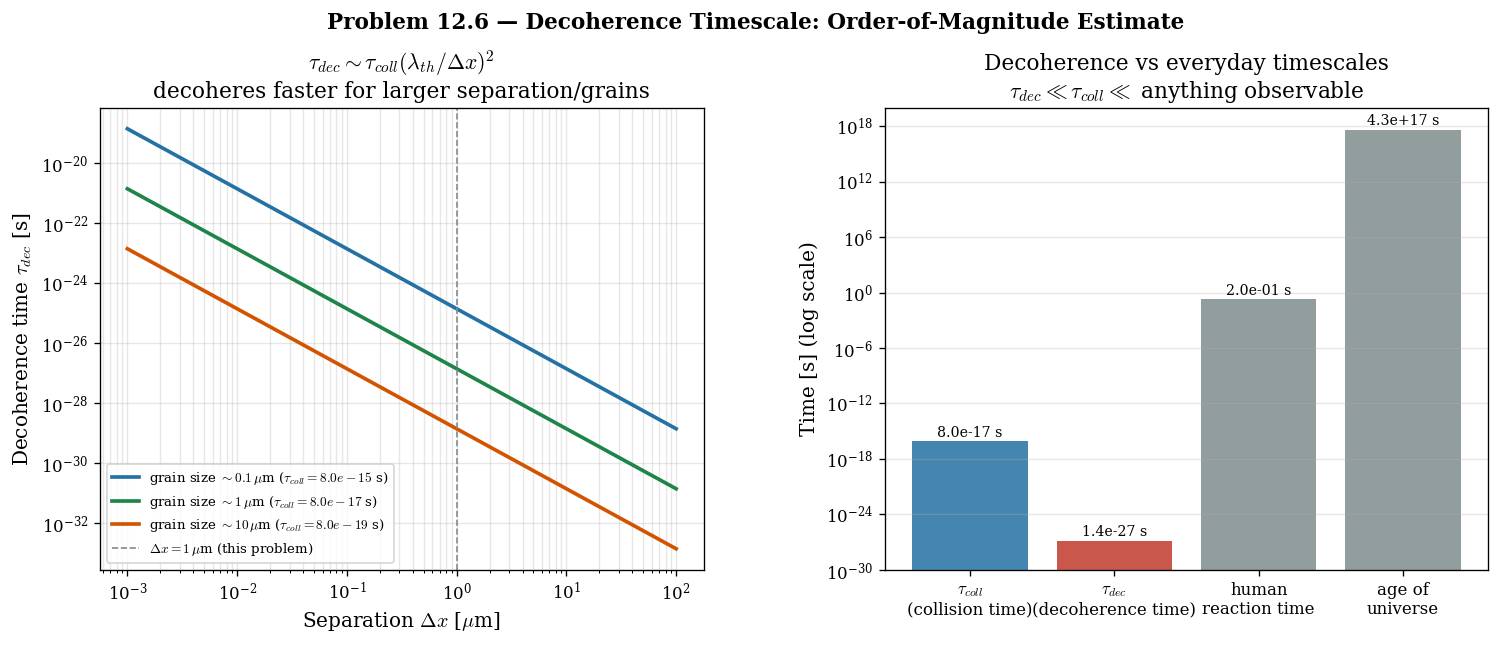

In [4]:

# Problem 12.6: Decoherence timescale tau_dec vs separation Delta_x

hbar = 1.054571817e-34
m_air = 5e-26       # kg, average air molecule mass
v_th  = 500.0       # m/s, mean thermal speed
n_air = 2.5e25      # m^-3, number density at room conditions
p_air = m_air * v_th
lam_th = hbar / p_air
print(f"Thermal momentum p_air = {p_air:.3e} kg m/s")
print(f"Thermal de Broglie wavelength lambda_th = {lam_th:.3e} m")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.08, right=0.97, wspace=0.30)

# Left: tau_dec vs Delta_x, for several grain sizes (cross sections) -> tau_coll
sizes = [1e-7, 1e-6, 1e-5]   # grain sizes in meters (cross section ~ size^2)
cols_sz = [BLUE, GREEN, ORG]
dx_arr = np.logspace(-9, -4, 200)  # separation Delta_x from 1nm to 100 micron

ax = axes[0]
for size, c in zip(sizes, cols_sz):
    sigma = size**2
    tau_coll = 1.0/(n_air*sigma*v_th)
    tau_dec = tau_coll / (dx_arr/lam_th)**2
    ax.loglog(dx_arr*1e6, tau_dec, color=c, lw=2.2,
              label=fr'grain size $\sim{size*1e6:.2g}\,\mu$m ($\tau_{{coll}}={tau_coll:.1e}$ s)')
ax.axvline(1.0, color=GRAY, ls='--', lw=1, label=r'$\Delta x=1\,\mu$m (this problem)')
ax.set_xlabel(r'Separation $\Delta x$ [$\mu$m]')
ax.set_ylabel(r'Decoherence time $\tau_{dec}$ [s]')
ax.set_title(r'$\tau_{dec}\sim\tau_{coll}(\lambda_{th}/\Delta x)^2$' + '\n'
              'decoheres faster for larger separation/grains')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, which='both')

# Compute the problem's specific numbers
dx = 1e-6
size0 = 1e-6
sigma0 = size0**2
tau_coll0 = 1.0/(n_air*sigma0*v_th)
tau_dec0 = tau_coll0 / (dx/lam_th)**2
print(f"\nFor 1-micron grain, Delta_x = 1 micron:")
print(f"  tau_coll = {tau_coll0:.3e} s")
print(f"  (Delta_x/lambda_th)^2 = {(dx/lam_th)**2:.3e}")
print(f"  tau_dec  = {tau_dec0:.3e} s")
print(f"  ratio tau_coll/tau_dec = {tau_coll0/tau_dec0:.3e}")

# Right: bar chart comparing timescales (log scale)
ax2 = axes[1]
labels = [r'$\tau_{coll}$'+'\n(collision time)', r'$\tau_{dec}$'+'\n(decoherence time)',
          'human\nreaction time', 'age of\nuniverse']
values = [tau_coll0, tau_dec0, 0.2, 4.3e17]
colors_bar = [BLUE, RED, GRAY, GRAY]
bars = ax2.bar(labels, values, color=colors_bar, alpha=0.85)
ax2.set_yscale('log')
for b,v in zip(bars, values):
    ax2.text(b.get_x()+b.get_width()/2, v*3, f'{v:.1e} s', ha='center', fontsize=8.5, rotation=0)
ax2.set_ylabel('Time [s] (log scale)')
ax2.set_title('Decoherence vs everyday timescales\n'
               r'$\tau_{dec}\ll\tau_{coll}\ll$ anything observable')
ax2.grid(True, alpha=0.3, axis='y', which='both')
ax2.set_ylim(1e-30, 1e20)

plt.suptitle('Problem 12.6 — Decoherence Timescale: Order-of-Magnitude Estimate',
              fontsize=13, fontweight='bold', y=1.04)
figures.append((fig, 'fig_12_6.png')); plt.show()


---
## Save All Figures & Download as ZIP

In [5]:
import os, zipfile
save_dir = 'ch12_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch12_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'\nZip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch12_figures/fig_12_2.png
Saved: ch12_figures/fig_12_3.png
Saved: ch12_figures/fig_12_6.png

Zip: ch12_figures.zip,  Files: ['fig_12_2.png', 'fig_12_3.png', 'fig_12_6.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
